In [ ]:
# import nltk
import yfinance as yf
import talib
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
apple_df=pd.read_csv('../data/raw/AAPL.csv')
amazon_df=pd.read_csv('../data/raw/AMZN.csv')
google_df=pd.read_csv('../data/raw/GOOG.csv')
meta_df=pd.read_csv('../data/raw/META.csv')
nvida_df=pd.read_csv('../data/raw/NVDA.csv')


In [ ]:
# TICKER='AMZN'
# apple_df.info()
# apple_df.isnull().sum()
# amazon_df.info()
# amazon_df.isnull().sum()
# google_df.info()
# google_df.isnull().sum()
# meta_df.info()
# meta_df.isnull().sum()
# nvida_df.info()
# nvida_df.isnull().sum()

Empty DataFrame
Columns: [Date, Close, High, Low, Open, Volume]
Index: []


In [ ]:
# print('Last 5 rows (Close vs SMA_20):')
# print(apple_df[['Close', 'SMA_20']].tail().round(2))
# amazon_df['Date']
amazon_df['Date'] = pd.to_datetime(amazon_df['Date'])
apple_df['Date'] = pd.to_datetime(apple_df['Date'])
google_df['Date'] = pd.to_datetime(google_df['Date'])
meta_df['Date'] = pd.to_datetime(meta_df['Date'])
nvida_df['Date'] = pd.to_datetime(nvida_df['Date'])
# print(apple_df.columns)
# apple_df['Date']

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


0      2009-01-02
1      2009-01-05
2      2009-01-06
3      2009-01-07
4      2009-01-08
          ...    
3769   2023-12-22
3770   2023-12-26
3771   2023-12-27
3772   2023-12-28
3773   2023-12-29
Name: Date, Length: 3774, dtype: datetime64[us]

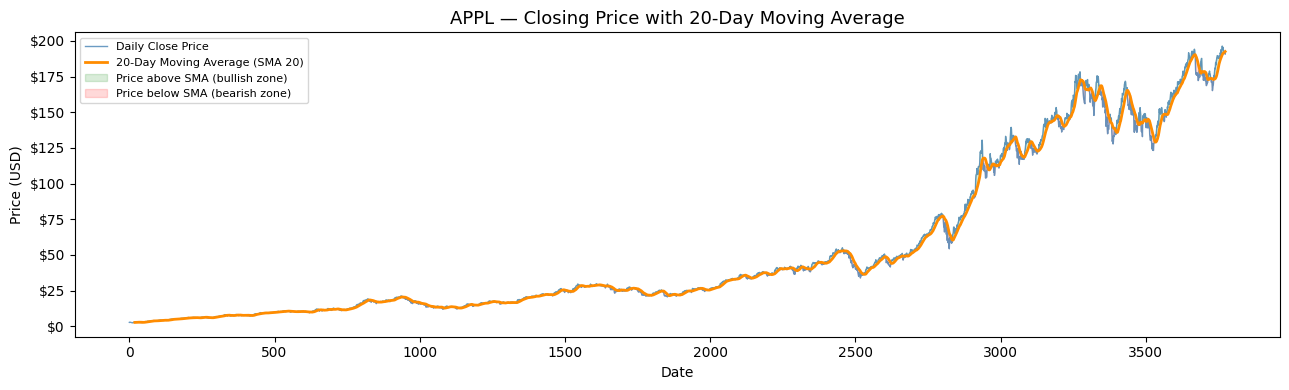

In [33]:
def plot_close_price_sma(TICKER,df,window):
        df['SMA_20'] = df['Close'].rolling(window).mean()
        fig, ax = plt.subplots(figsize=(13, 4))

        ax.plot(df.index, df['Close'],  color='steelblue', linewidth=1,
                alpha=0.8, label='Daily Close Price')
        ax.plot(df.index, df['SMA_20'], color='darkorange', linewidth=2,
                label='20-Day Moving Average (SMA 20)')

        # Highlight areas where price is above vs below the SMA
        ax.fill_between(apple_df.index, apple_df['Close'], apple_df['SMA_20'],
                        where=(df['Close'] >= apple_df['SMA_20']),
                        alpha=0.15, color='green', label='Price above SMA (bullish zone)')
        ax.fill_between(df.index, df['Close'], apple_df['SMA_20'],
                        where=(df['Close'] < apple_df['SMA_20']),
                        alpha=0.15, color='red', label='Price below SMA (bearish zone)')

        ax.set_title(f'{TICKER} — Closing Price with 20-Day Moving Average', fontsize=13)
        ax.set_ylabel('Price (USD)')
        ax.set_xlabel('Date')
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
        ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()


plot_close_price_sma('APPL',apple_df,20)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'EMA_20'], dtype='str')
               Close      High       Low      Open      Volume    EMA_20  \
Date                                                                       
2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200  2.721686   
2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400  2.722258   
2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400  2.722594   
2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800  2.722628   
2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800  2.722914   

               EMA_9  
Date                  
2009-01-02  2.721686  
2009-01-05  2.733173  
2009-01-06  2.738832  
2009-01-07  2.737898  
2009-01-08  2.742125  


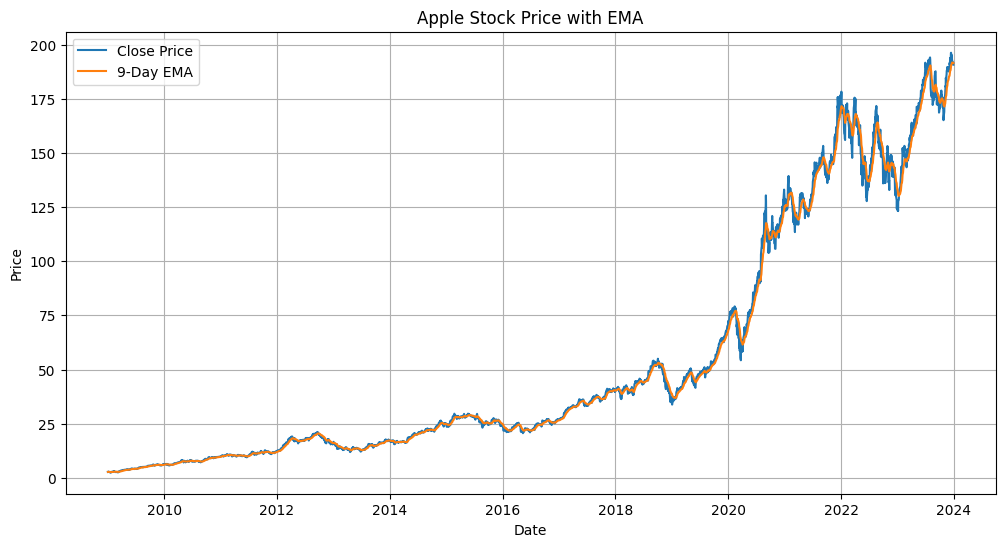

In [59]:
def plot_close_price_ema(df,span):
    print(df.columns)
    # df.set_index('Date', inplace=True)

    # Calculate EMA
    df[f'EMA_{span}'] = df['Close'].ewm(span, adjust=False).mean()

    print(df.head())
    plt.figure(figsize=(12, 6))

    # Plot Close Price
    plt.plot(df.index, df['Close'], label='Close Price')

    # Plot EMA
    plt.plot(df.index, df[f'EMA_{span}'], label=f'{span}-Day EMA')

    # Labels and Title
    plt.title('Apple Stock Price with EMA')
    plt.xlabel('Date')
    plt.ylabel('Price')

    # Legend
    plt.legend()

    # Grid
    plt.grid(True)

    plt.show()
    
plot_close_price_ema(apple_df,9)

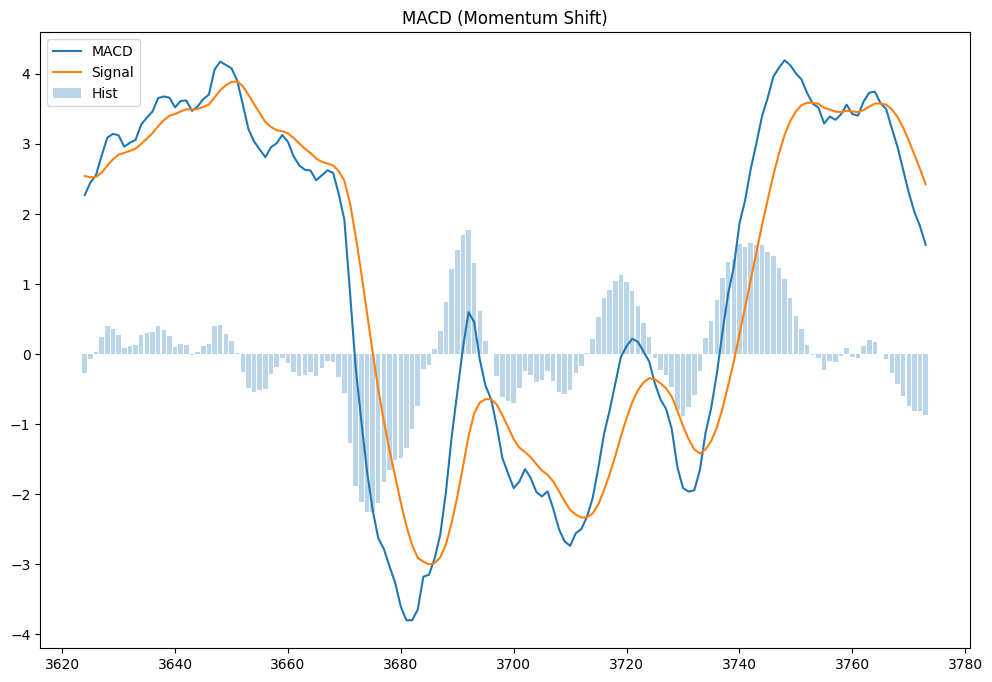

In [32]:
def plot_rsi(df):
    fig, (ax2) = plt.subplots(figsize=(12, 8), sharex=True)
    ax2.plot(df.index[-150:], df['RSI'][-150:], color='purple', label='RSI')
    ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
    ax2.axhline(30, color='green', linestyle='--', alpha=0.5)
    ax2.set_title("RSI (Overbought/Oversold)")
    plt.show()



def plot_macd(df):
    fig, (ax1) = plt.subplots( figsize=(12, 8), sharex=True)
    # MACD
    ax1.plot(df.index[-150:], df['macd'][-150:], label='MACD')
    ax1.plot(df.index[-150:], df['macdsignal'][-150:], label='Signal')
    ax1.bar(df.index[-150:], df['macdhist'][-150:], label='Hist', alpha=0.3)
    ax1.set_title("MACD (Momentum Shift)")
    ax1.legend()
    plt.show()
    
plot_macd(apple_df)
    


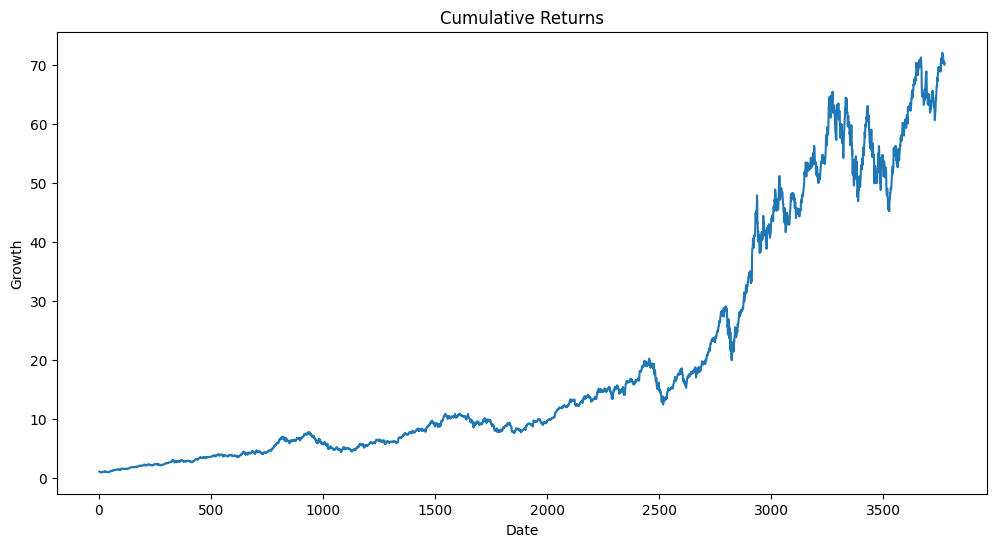

,Date,Close,High,Low,Open,Volume,EMA_20,RSI,macd,macdsignal,macdhist,SMA_20,SMA_50,MACD,Signal,Hist,Daily_Return,Cumulative_Return
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042204,1.042204
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.016494,1.025014
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021609,1.002865
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018570,1.021488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3769,2023-12-22,191.788757,193.581821,191.164647,193.353962,37149600,191.510231,54.672784,2.633141,3.235256,-0.602115,191.856618,183.572859,2.633141,3.235256,-0.602115,-0.005548,70.466884
3770,2023-12-26,191.243912,192.076049,191.025969,191.798670,28919300,191.484867,53.090049,2.304751,3.049155,-0.744404,192.018094,183.858864,2.304751,3.049155,-0.744404,-0.002841,70.266697
3771,2023-12-27,191.342972,191.689703,189.302247,190.689158,48087700,191.471353,53.354446,2.029104,2.845145,-0.816041,192.154308,184.149424,2.029104,2.845145,-0.816041,0.000518,70.303094
3772,2023-12-28,191.768951,192.838849,191.362784,192.323710,34049900,191.499696,54.540999,1.823998,2.640915,-0.816918,192.362839,184.479567,1.823998,2.640915,-0.816918,0.002226,70.459607


In [34]:
#Use PyNance to compute additional financial metrics beyond standard indicators
def cumulative_return(df):
    df = df.copy()

    df["Daily_Return"] = df["Close"].pct_change()

    df["Cumulative_Return"] = (
        1 + df["Daily_Return"]
    ).cumprod()
    
    plt.figure(figsize=(12,6))

    plt.plot(
        df.index,
        df["Cumulative_Return"]
    )

    plt.title("Cumulative Returns")
    plt.xlabel("Date")
    plt.ylabel("Growth")

    plt.show()

    return df

cumulative_return(apple_df)


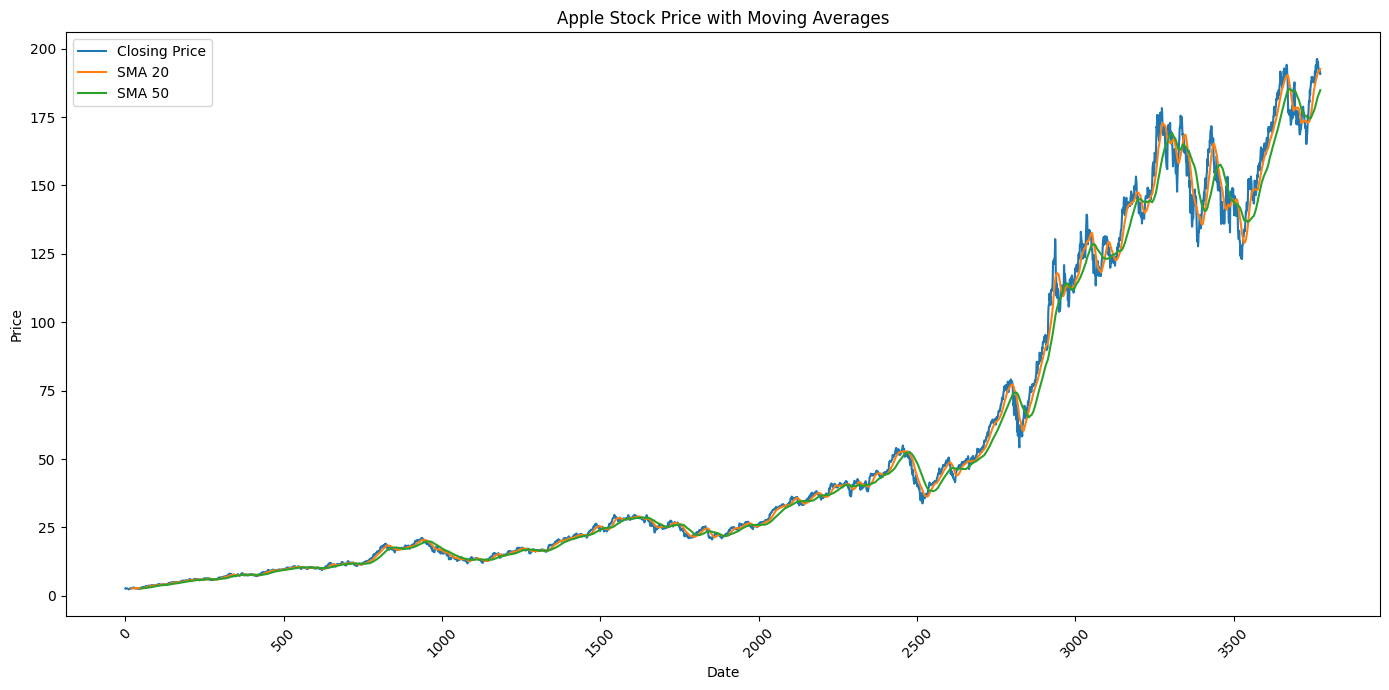

In [35]:
#Visualize the Data
#Plot closing prices overlaid with moving averages 
def visualize_closing_price(df,name):
    df["SMA_20"] = (
        df["Close"]
        .rolling(window=20)
        .mean()
    )

    df["SMA_50"] = (
        df["Close"]
        .rolling(window=50)
        .mean()
    )
    plt.figure(figsize=(14,7))

    # Closing price
    plt.plot(
        df.index,
        df["Close"],
        label="Closing Price"
    )

    # 20-day SMA
    plt.plot(
        df.index,
        df["SMA_20"],
        label="SMA 20"
    )

    # 50-day SMA
    plt.plot(
        df.index,
        df["SMA_50"],
        label="SMA 50"
    )

    plt.title(f"{name} Stock Price with Moving Averages")

    plt.xlabel("Date")
    plt.ylabel("Price")

    plt.legend()

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()
    
visualize_closing_price(apple_df,'Apple')

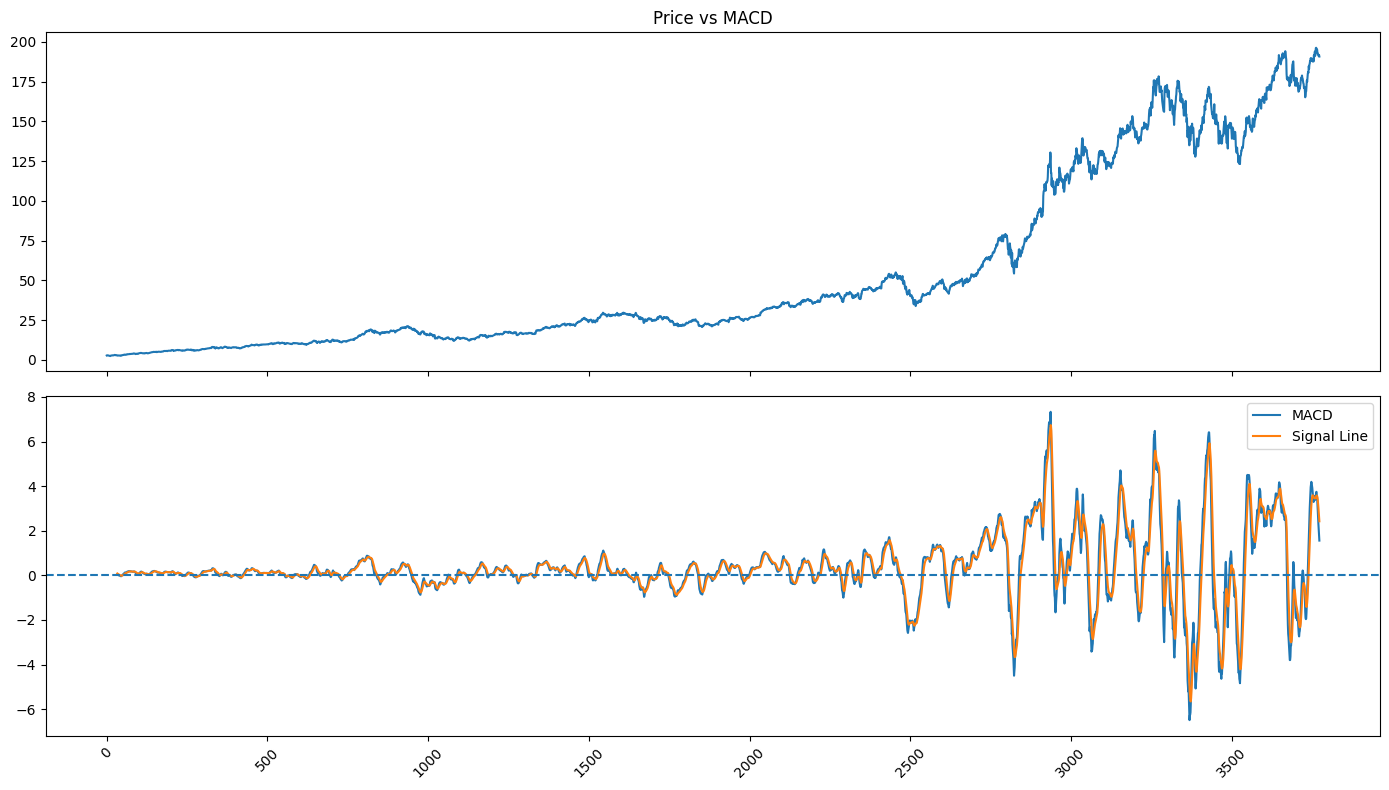

In [28]:
def price_vs_rsi(df):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), sharex=True)

    # Price
    ax1.plot(df.index, df["Close"], label="Close Price")
    ax1.set_title("Price vs RSI")
    ax1.legend()

    # RSI
    ax2.plot(df.index, df["RSI"], color="purple", label="RSI")
    ax2.axhline(70, linestyle="--", color="red")
    ax2.axhline(30, linestyle="--", color="green")
    ax2.legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
def price_vs_macd(df):
    macd, signal, hist = talib.MACD(
    df["Close"],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
    )

    df["MACD"] = macd
    df["Signal"] = signal
    df["Hist"] = hist
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), sharex=True)

    ax1.plot(df.index, df["Close"])
    ax1.set_title("Price vs MACD")

    ax2.plot(df.index, df["MACD"], label="MACD")
    ax2.plot(df.index, df["Signal"], label="Signal Line")
    ax2.axhline(0, linestyle="--")

    ax2.legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    
# price_vs_rsi(apple_df)
price_vs_macd(apple_df)